*@author: petra.boskovic*

# 1. Install dependencies and imports

In [ ]:
#!pip install kagglehub opencv-python torch torchvision

In [12]:
import glob
import json
import os
import random
import shutil

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                              precision_score, recall_score, roc_auc_score, roc_curve)
import matplotlib.pyplot as plt

import kagglehub

# 2. Configuration

In [2]:
KAGGLE_DATASET_SLUG = "nikanvasei/traffic-anomaly-dataset-tad"

In [3]:
PROJECT_ROOT = "/content/tad_project"
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
RAW_DATA_DIR = os.path.join(DATA_DIR, "raw")
FRAMES_DIR = os.path.join(DATA_DIR, "frames")
FEATURES_DIR = os.path.join(DATA_DIR, "features")
PROCESSED_DIR = os.path.join(DATA_DIR, "processed")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
REPORTS_DIR = os.path.join(PROJECT_ROOT, "reports")

In [4]:
for d in [DATA_DIR, RAW_DATA_DIR, FRAMES_DIR, FEATURES_DIR,
          PROCESSED_DIR, MODELS_DIR, REPORTS_DIR]:
    os.makedirs(d, exist_ok=True)

In [5]:
# Image size
FRAME_SIZE = (224, 224)

In [6]:
# Sliding-window sequences
WINDOW_SIZE = 16                  # frames per window
WINDOW_STRIDE = 8                 # step between windows (50% overlap)

In [7]:
# Train / val / test split (done at VIDEO level to avoid leakage across splits)
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15
RANDOM_SEED = 42

In [8]:
# CNN feature extractor
FEATURE_DIM = 512                 # resnet18 penultimate-layer embedding size

In [9]:
# Model / training hyperparameters
BATCH_SIZE = 32
NUM_EPOCHS = 25
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
LSTM_HIDDEN_SIZE = 128
DROPOUT = 0.3

In [18]:
# Known label-folder names -> binary label (used during EDA below)
BINARY_LABEL_MAP = {
    "normal": 0,
    "abnormal": 1,
    "anomaly": 1,
    "anomalous": 1,
    "train_normal": 0,
    "test_normal": 0,
    "test_anomaly": 1,
}

In [11]:
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


# 3. Download the dataset (kagglehub)

In [13]:
if os.listdir(RAW_DATA_DIR):
    print(f"'{RAW_DATA_DIR}' already has files - skipping download.")
else:
    print(f"Downloading '{KAGGLE_DATASET_SLUG}' ...")
    cache_path = kagglehub.dataset_download(KAGGLE_DATASET_SLUG)
    print(f"kagglehub cached the dataset at: {cache_path}")

    if os.path.abspath(cache_path) != os.path.abspath(RAW_DATA_DIR):
        for item in os.listdir(cache_path):
            src = os.path.join(cache_path, item)
            dst = os.path.join(RAW_DATA_DIR, item)
            if os.path.isdir(src):
                shutil.copytree(src, dst, dirs_exist_ok=True)
            else:
                shutil.copy2(src, dst)

n_files = sum(len(f) for _, _, f in os.walk(RAW_DATA_DIR))
print(f"OUTPUT: {n_files} files available under {RAW_DATA_DIR}")

100%|██████████| 12.5G/12.5G [02:09<00:00, 103MB/s]

Extracting files...


kagglehub cached the dataset at: /root/.cache/kagglehub/datasets/nikanvasei/traffic-anomaly-dataset-tad/versions/1
OUTPUT: 538531 files available under /content/tad_project/data/raw


# 4. Exploratory data analysis + structure discovery

In [16]:
# file type counts
ext_counts = pd.Series([
    os.path.splitext(f)[1].lower()
    for _, _, files in os.walk(RAW_DATA_DIR)
    for f in files
]).value_counts()
print("File type counts:")
print(ext_counts)

File type counts:
.jpg    538522
.db          9
Name: count, dtype: int64


In [21]:
# Mapping: video_id -> (path, label)
# Label is assigned based on whether the path contains "normal" or "abnormal"

video_folders = {}
for dirpath, _, filenames in os.walk(RAW_DATA_DIR):
    jpg_files = [f for f in filenames if f.lower().endswith(".jpg")]
    if not jpg_files:
        continue

    rel = os.path.relpath(dirpath, RAW_DATA_DIR).lower()
    parts = rel.replace("-", "_").split(os.sep)

    # Determine label from folder names in the path
    label = None
    for part in parts:
        if part in BINARY_LABEL_MAP:
            label = BINARY_LABEL_MAP[part]
            break

    if label is None:
        continue  # skip if we cannot determine the label

    # Video ID = relative path (to keep it unique)
    video_id = rel.replace(os.sep, "_")
    video_folders[video_id] = {"path": dirpath, "label": label, "n_images": len(jpg_files)}

video_ids = sorted(video_folders.keys())
print(f"\nFound {len(video_ids)} video folders.")
print(f"  Normal (0): {sum(1 for v in video_ids if video_folders[v]['label']==0)}")
print(f"  Abnormal (1): {sum(1 for v in video_ids if video_folders[v]['label']==1)}")

for v in video_ids[:5]:
    info = video_folders[v]
    print(f"  {v}: {info['n_images']} images, label={info['label']}")

# Warn if very few folders are found
if len(video_ids) < 10:
    print("\nWARNING: Very few video folders found!")
    print("If all images sit directly inside normal/ and abnormal/ without subfolders,")
    print("you need to add file-name grouping logic.")


Found 510 video folders.
  Normal (0): 250
  Abnormal (1): 260
  tad_frames_abnormal_01_accident_001.mp4: 224 images, label=1
  tad_frames_abnormal_01_accident_002.mp4: 220 images, label=1
  tad_frames_abnormal_01_accident_003.mp4: 199 images, label=1
  tad_frames_abnormal_01_accident_004.mp4: 190 images, label=1
  tad_frames_abnormal_01_accident_005.mp4: 318 images, label=1


# 5. CNN feature extraction (directly from .jpg images)

In [22]:
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
resnet.fc = nn.Identity()
resnet.eval().to(DEVICE)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 165MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [23]:
preprocess = transforms.Compose([
    transforms.Resize(FRAME_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [24]:
print(f"\nExtracting features for {len(video_ids)} video folders...")

for i, vid in enumerate(video_ids, 1):
    out_path = os.path.join(FEATURES_DIR, f"{vid}.npy")
    if os.path.exists(out_path):
        continue

    vpath = video_folders[vid]["path"]
    frame_files = sorted(f for f in os.listdir(vpath) if f.lower().endswith(".jpg"))

    feats = []
    batch = []
    for fname in frame_files:
        img = Image.open(os.path.join(vpath, fname)).convert("RGB")
        batch.append(preprocess(img))
        if len(batch) == 64:
            with torch.no_grad():
                feats.append(resnet(torch.stack(batch).to(DEVICE)).cpu().numpy())
            batch = []

    if batch:
        with torch.no_grad():
            feats.append(resnet(torch.stack(batch).to(DEVICE)).cpu().numpy())

    feats = np.concatenate(feats, axis=0) if feats else np.zeros((0, FEATURE_DIM), dtype=np.float32)
    np.save(out_path, feats)
    print(f"  [{i}/{len(video_ids)}] {vid}: shape {feats.shape}")

print(f"\nFeatures saved to: {FEATURES_DIR}")


Extracting features for 510 video folders...
  [1/510] tad_frames_abnormal_01_accident_001.mp4: shape (224, 512)
  [2/510] tad_frames_abnormal_01_accident_002.mp4: shape (220, 512)
  [3/510] tad_frames_abnormal_01_accident_003.mp4: shape (199, 512)
  [4/510] tad_frames_abnormal_01_accident_004.mp4: shape (190, 512)
  [5/510] tad_frames_abnormal_01_accident_005.mp4: shape (318, 512)
  [6/510] tad_frames_abnormal_01_accident_006.mp4: shape (267, 512)
  [7/510] tad_frames_abnormal_01_accident_007.mp4: shape (327, 512)
  [8/510] tad_frames_abnormal_01_accident_008.mp4: shape (271, 512)
  [9/510] tad_frames_abnormal_01_accident_009.mp4: shape (183, 512)
  [10/510] tad_frames_abnormal_01_accident_010.mp4: shape (210, 512)
  [11/510] tad_frames_abnormal_01_accident_011.mp4: shape (236, 512)
  [12/510] tad_frames_abnormal_01_accident_012.mp4: shape (63, 512)
  [13/510] tad_frames_abnormal_01_accident_013.mp4: shape (299, 512)
  [14/510] tad_frames_abnormal_01_accident_014.mp4: shape (244, 512

# 6. Window preparation and train/val/test split

In [25]:
train_ids, temp_ids = train_test_split(
    video_ids, train_size=TRAIN_RATIO, random_state=RANDOM_SEED,
    stratify=[video_folders[v]["label"] for v in video_ids]  # preserve class ratio
)

relative_val = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
val_ids, test_ids = train_test_split(
    temp_ids, train_size=relative_val, random_state=RANDOM_SEED,
    stratify=[video_folders[v]["label"] for v in temp_ids]
)

print(f"Split -> train: {len(train_ids)}, val: {len(val_ids)}, test: {len(test_ids)}")

Split -> train: 357, val: 76, test: 77


In [26]:
splits = {"train": train_ids, "val": val_ids, "test": test_ids}
split_arrays = {}

for split_name, ids in splits.items():
    X, y, meta_vids = [], [], []
    for vid in ids:
        feat_path = os.path.join(FEATURES_DIR, f"{vid}.npy")
        if not os.path.exists(feat_path):
            continue
        features = np.load(feat_path)
        n_frames = features.shape[0]
        if n_frames < WINDOW_SIZE:
            continue

        # Binary label: every frame in this video has the same label
        label = video_folders[vid]["label"]

        # Build sliding windows
        for start in range(0, n_frames - WINDOW_SIZE + 1, WINDOW_STRIDE):
            end = start + WINDOW_SIZE
            if end > n_frames:
                break
            X.append(features[start:end])
            y.append(label)
            meta_vids.append(vid)

    X = np.stack(X).astype(np.float32) if X else np.zeros((0, WINDOW_SIZE, FEATURE_DIM), dtype=np.float32)
    y = np.array(y, dtype=np.int64)
    split_arrays[split_name] = (X, y, meta_vids)

    out_path = os.path.join(PROCESSED_DIR, f"{split_name}.npz")
    np.savez_compressed(out_path, X=X, y=y, video_ids=np.array(meta_vids))
    pos_rate = y.mean() if len(y) else 0
    print(f"  {split_name}: {X.shape[0]} windows, anomaly rate: {pos_rate:.3f}")

  train: 46284 windows, anomaly rate: 0.152
  val: 10543 windows, anomaly rate: 0.163
  test: 9764 windows, anomaly rate: 0.150


In [27]:
X_train, y_train, _ = split_arrays["train"]
X_val, y_val, _ = split_arrays["val"]
X_test, y_test, _ = split_arrays["test"]

# 7. Model definition (binary classification)

In [28]:
class LSTMBinaryClassifier(nn.Module):
    def __init__(self, input_dim=FEATURE_DIM, hidden_size=LSTM_HIDDEN_SIZE, dropout=DROPOUT):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_size, batch_first=True)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, 1),  # single output for binary classification
        )

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.classifier(h_n[-1]).squeeze(-1)  # (batch,)


In [29]:
model = LSTMBinaryClassifier().to(DEVICE)

In [30]:
n_params = sum(p.numel() for p in model.parameters())
print(f"Model: LSTMBinaryClassifier, parameters: {n_params:,}")

Model: LSTMBinaryClassifier, parameters: 337,025


# 8. Training (binary classification with BCEWithLogitsLoss)

In [31]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
ckpt_path = os.path.join(MODELS_DIR, "lstm_binary_classifier.pt")

In [107]:
# Loss weighting for imbalanced classes
pos_rate = max(y_train.mean(), 1e-6)
pos_weight = torch.tensor([(1 - pos_rate) / pos_rate], device=DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

In [108]:
X_train_t = torch.from_numpy(X_train).float()
y_train_t = torch.from_numpy(y_train).float()
X_val_t = torch.from_numpy(X_val).float().to(DEVICE)
y_val_t = torch.from_numpy(y_val).float().to(DEVICE)

In [109]:
best_val_loss = float("inf")
for epoch in range(1, NUM_EPOCHS + 1):
    perm = torch.randperm(len(X_train_t))
    model.train()
    train_loss = 0.0
    for start in range(0, len(perm), BATCH_SIZE):
        idx = perm[start:start + BATCH_SIZE]
        xb = X_train_t[idx].to(DEVICE)
        yb = y_train_t[idx].to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(idx)
    train_loss /= len(X_train_t)

    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_val_t), y_val_t).item()

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), ckpt_path)

print(f"\nBest model saved: {ckpt_path} (val_loss={best_val_loss:.4f})")

Epoch 01/25 | train_loss: 0.0129 | val_loss: 1.4445
Epoch 02/25 | train_loss: 0.0115 | val_loss: 3.9823
Epoch 03/25 | train_loss: 0.0115 | val_loss: 1.6355
Epoch 04/25 | train_loss: 0.0101 | val_loss: 2.0933
Epoch 05/25 | train_loss: 0.0137 | val_loss: 1.5409
Epoch 06/25 | train_loss: 0.0115 | val_loss: 2.5388
Epoch 07/25 | train_loss: 0.0141 | val_loss: 3.1759
Epoch 08/25 | train_loss: 0.0167 | val_loss: 2.1520
Epoch 09/25 | train_loss: 0.0110 | val_loss: 3.1393
Epoch 10/25 | train_loss: 0.0143 | val_loss: 3.6498
Epoch 11/25 | train_loss: 0.0089 | val_loss: 1.6217
Epoch 12/25 | train_loss: 0.0129 | val_loss: 3.6768
Epoch 13/25 | train_loss: 0.0069 | val_loss: 3.3227
Epoch 14/25 | train_loss: 0.0080 | val_loss: 1.6582
Epoch 15/25 | train_loss: 0.0121 | val_loss: 3.0858
Epoch 16/25 | train_loss: 0.0138 | val_loss: 5.2956
Epoch 17/25 | train_loss: 0.0047 | val_loss: 1.6490
Epoch 18/25 | train_loss: 0.0138 | val_loss: 2.2712
Epoch 19/25 | train_loss: 0.0061 | val_loss: 2.2928
Epoch 20/25 

# 9. Evaluation (binary metrics)

In [110]:
model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
model.eval()

LSTMBinaryClassifier(
  (lstm): LSTM(512, 128, batch_first=True)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [127]:
X_test_t = torch.from_numpy(X_test).float().to(DEVICE)
with torch.no_grad():
    probs = torch.sigmoid(model(X_test_t)).cpu().numpy()

preds = (probs >= 0.01).astype(int)

metrics = {
    "accuracy": accuracy_score(y_test, preds),
    "precision": precision_score(y_test, preds, zero_division=0),
    "recall": recall_score(y_test, preds, zero_division=0),
    "f1": f1_score(y_test, preds, zero_division=0),
}

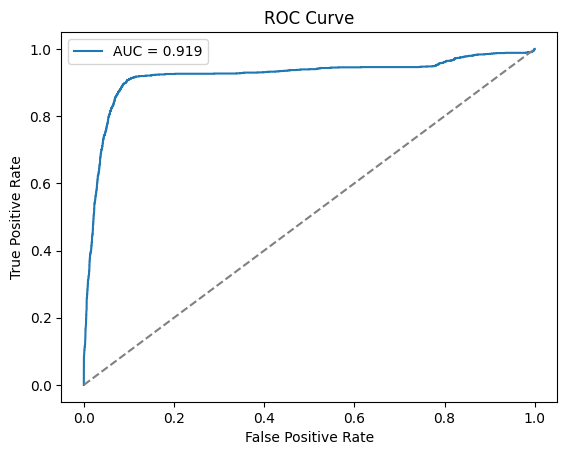

In [128]:
if len(np.unique(y_test)) > 1:
    metrics["roc_auc"] = roc_auc_score(y_test, probs)
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {metrics['roc_auc']:.3f}")
    plt.plot([0, 1], [0, 1], "--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.savefig(os.path.join(REPORTS_DIR, "roc_curve.png"), dpi=150)
    plt.show()

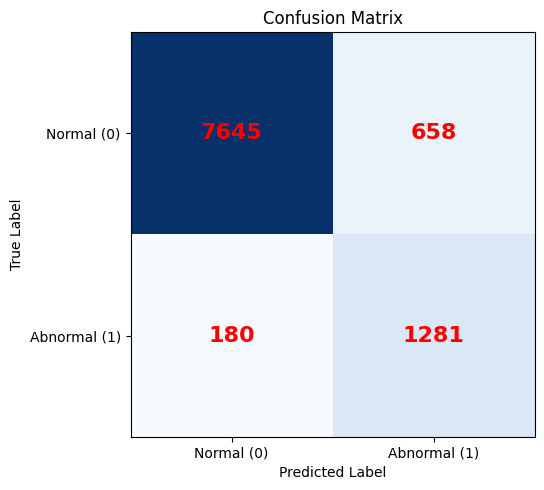

In [129]:
cm = confusion_matrix(y_test, preds)
class_names = ["Normal (0)", "Abnormal (1)"]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")

# Ticks and labels
ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("Confusion Matrix")

# Add text annotations inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        text = ax.text(j, i, str(cm[i, j]),
                       ha="center", va="center", color="red", fontsize=16, fontweight="bold")

fig.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

In [130]:
print("\nTest metrics:")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}")


Test metrics:
  accuracy: 0.9142
  precision: 0.6606
  recall: 0.8768
  f1: 0.7535
  roc_auc: 0.9195


In [131]:
with open(os.path.join(REPORTS_DIR, "test_metrics.json"), "w") as f:
    json.dump(metrics, f, indent=2)

# 10. Inference on a new image folder

In [132]:
INFERENCE_FOLDER = None  # e.g. "/content/tad_project/data/raw/normal/video_xyz"

if INFERENCE_FOLDER and os.path.isdir(INFERENCE_FOLDER):
    frame_files = sorted(f for f in os.listdir(INFERENCE_FOLDER) if f.lower().endswith(".jpg"))
    feats = []
    batch = []
    for fname in frame_files:
        img = Image.open(os.path.join(INFERENCE_FOLDER, fname)).convert("RGB")
        batch.append(preprocess(img))
        if len(batch) == 64:
            with torch.no_grad():
                feats.append(resnet(torch.stack(batch).to(DEVICE)).cpu().numpy())
            batch = []
    if batch:
        with torch.no_grad():
            feats.append(resnet(torch.stack(batch).to(DEVICE)).cpu().numpy())

    feats = np.concatenate(feats, axis=0)
    if feats.shape[0] < WINDOW_SIZE:
        raise RuntimeError(f"Too few images: {feats.shape[0]}, need >= {WINDOW_SIZE}")

    windows = []
    for start in range(0, feats.shape[0] - WINDOW_SIZE + 1, WINDOW_STRIDE):
        windows.append(feats[start:start + WINDOW_SIZE])
    X_inf = torch.from_numpy(np.stack(windows).astype(np.float32)).to(DEVICE)

    with torch.no_grad():
        scores = torch.sigmoid(model(X_inf)).cpu().numpy()

    # Threshold = 90th percentile
    thresh = np.percentile(scores, 90)
    print(f"\nInference results ({len(scores)} windows):")
    for i, s in enumerate(scores):
        flag = " <<< ANOMALY" if s >= thresh else ""
        print(f"  Window {i:3d}: score={s:.4f}{flag}")

    plt.figure(figsize=(10, 3))
    plt.plot(scores, label="Anomaly score")
    plt.axhline(thresh, color="red", linestyle="--", label="90th percentile")
    plt.xlabel("Window index")
    plt.ylabel("Anomaly probability")
    plt.title("Anomaly score over time")
    plt.legend()
    plt.ylim(0, 1)
    plt.show()
else:
    print("Set INFERENCE_FOLDER to a path containing .jpg images to run inference.")

Set INFERENCE_FOLDER to a path containing .jpg images to run inference.
